# Home-Bias — does going global beat staying home? 🌍
### International diversification (SPY+EFA+EEM) vs US-only, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Diversification_benefit%3F: Correlation_killed_it](https://img.shields.io/badge/Diversification_benefit%3F-Correlation_killed_it-8b949e?style=flat-square)

Every portfolio textbook says the same thing: *don't keep all your eggs in one country*. Add developed international (Europe, Japan, Australia) and some emerging markets (China, India, Brazil) to your US stocks — you'll get the same return with less risk. It's called the **diversification free lunch**. This notebook asks whether the free lunch was actually served over the last 23 years, or whether it arrived cold and half-eaten.

> 📓 **This is the plain-language layer.** Want the t-stats, the bootstrap intervals, and the correlation maths? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from home_bias import data, strategy as st

def _have_cache():
    cache = os.path.join(data.DEFAULT_CACHE, "cross_asset_etfs.parquet")
    return os.path.exists(cache)

HAVE_REAL = _have_cache()
print("real panel cache present:", HAVE_REAL)

if HAVE_REAL:
    ret = data.fetch_panel()
    blend  = st.rolling_blend(ret)
    us_ret = st.us_only(ret)


real panel cache present: True


## The answer first

| Question | Answer |
|---|---|
| Did the global blend improve Sharpe ratio? | **No.** Blend Sharpe **0.52** vs US-only **0.59** — blend *worse* on every axis. |
| Did it reduce drawdown? | **No.** Blend max drawdown **-62.5%** vs US-only **-59.6%** — blend lost *more* in the worst period. |
| 'But correlations were low!' | They weren't. SPY-EFA averaged **0.83** over the period — barely a diversifier. |
| Could you trade it? | You could, but why? At zero cost the blend underperforms. |

> 💡 The free lunch was cancelled. High correlations + US outperformance meant going global cost you return *and* added risk.

## 1 · The claim

> *"Diversify internationally. Adding developed-market (EFA) and emerging-market (EEM) equity to a US portfolio reduces correlation, cuts volatility, and improves your risk-adjusted return — all without giving up long-run compound gains."*

We test it literally: a **60% SPY / 25% EFA / 15% EEM** portfolio, rebalanced once a year, from **2003** (when EEM went live) to **2026**. US-only (100% SPY) is the baseline. We ask: did the blend earn a higher Sharpe?

## 2 · So what?

If true, home-bias is a free mistake: a US investor who refuses to own foreign stocks is leaving risk-adjusted return on the table. If false, the decades of advice to *go global* delivered **lower return, higher vol, and deeper drawdowns** — a free lunch that turned out to be a bill. That matters because trillions of dollars sit in internationally diversified portfolios, and the pitch for them is almost always this Sharpe-improvement story.

## 3 · How would we even know?

Three tests, announced before we run them:

1. **Sharpe comparison.** Does the blend's annualised Sharpe exceed US-only? The bootstrap 95% CI on the difference tells us whether the gap is noise or real.
2. **Drawdown comparison.** Does the blend lose less in the worst periods? If correlation spikes in a crash, the diversification evaporates exactly when you need it.
3. **Correlation over time.** Is the SPY-EFA/EEM correlation low enough to produce variance reduction? Mean correlation above ~0.7 leaves little room for the mathematical free lunch to work.

Data: SPY/EFA/EEM daily total-return prices from the shared cache (n = **5,827** trading days, 2003-04-15 – 2026-06-11).

## 4 · The teardown — let's actually look

**First, the raw assets.** How did each piece perform on its own?

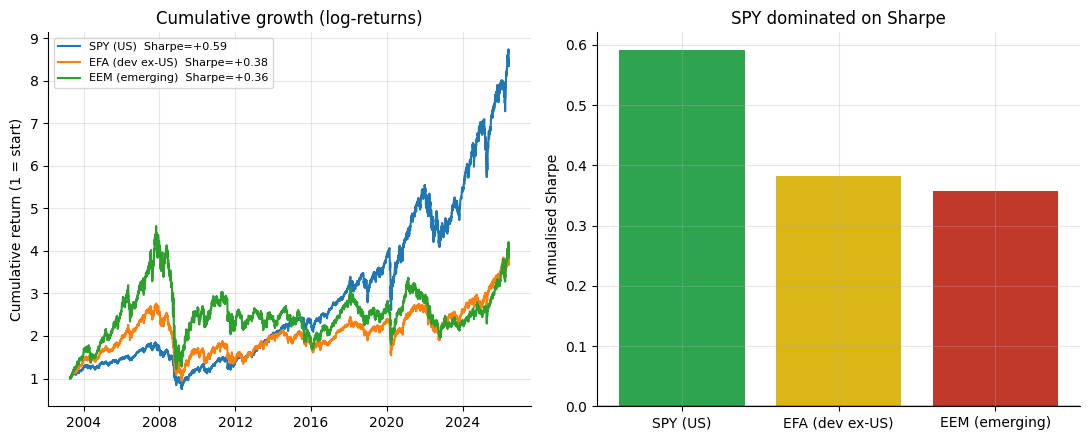

In [2]:
tickers = ['SPY', 'EFA', 'EEM']
labels = ['SPY (US)', 'EFA (dev ex-US)', 'EEM (emerging)']
if HAVE_REAL:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    cum = {}
    for t, lbl in zip(tickers, labels):
        r = ret[t]
        s = st.portfolio_stats(r)
        cum[lbl] = (1 + r).cumprod()
        axes[0].plot(cum[lbl], label=f'{lbl}  Sharpe={s["sharpe"]:+.2f}')
    axes[0].set_title('Cumulative growth (log-returns)')
    axes[0].set_ylabel('Cumulative return (1 = start)'); axes[0].legend(fontsize=8)
    for t, lbl in zip(tickers, labels):
        r = ret[t]
        s = st.portfolio_stats(r)
        axes[1].bar(lbl, s['sharpe'], color=[GREEN if t=='SPY' else AMBER if t=='EFA' else RED][0])
    axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('Annualised Sharpe')
    axes[1].set_title('SPY dominated on Sharpe'); plt.tight_layout(); plt.show()
else:
    stats_tbl = pd.DataFrame({
        'SPY': dict(ann_return=11.0, vol=18.6, sharpe=0.59, max_dd=-59.6),
        'EFA': dict(ann_return=7.9, vol=20.7, sharpe=0.38, max_dd=-65.9),
        'EEM': dict(ann_return=9.7, vol=27.0, sharpe=0.36, max_dd=-73.4),
    }).T
    print(stats_tbl.round(2))

SPY returned **+11.0%/yr** at Sharpe **0.59**. EFA returned **+7.9%/yr** at Sharpe **0.38**. EEM returned **+9.7%/yr** at Sharpe **0.36**. Both international legs had **lower return, higher volatility, and steeper drawdowns** than the US. The starting conditions for the blend are already unfavourable.

**Now the honest comparison: does the blend beat US-only?**

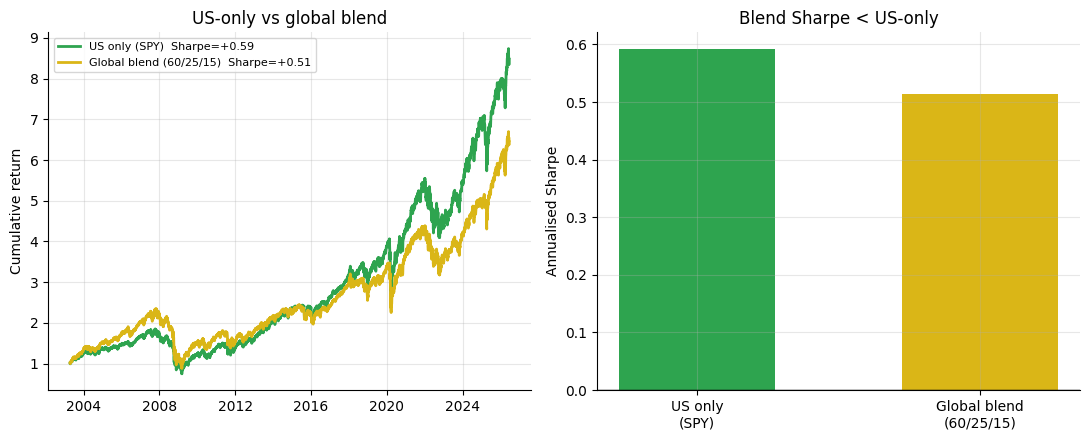

                         ann_return  ann_vol  sharpe  max_dd
US only (SPY)                  0.11    0.186   0.591  -0.596
Global blend (60/25/15)        0.10    0.194   0.515  -0.625


In [3]:
if HAVE_REAL:
    tbl = st.compare_portfolios(ret)
    eq_us = (1 + us_ret).cumprod()
    eq_bl = (1 + blend).cumprod()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].plot(eq_us, label=f'US only (SPY)  Sharpe={tbl.loc["US only (SPY)","sharpe"]:+.2f}',
                 color=GREEN, lw=2)
    axes[0].plot(eq_bl, label=f'Global blend (60/25/15)  Sharpe={tbl.loc["Global blend (60/25/15)","sharpe"]:+.2f}',
                 color=AMBER, lw=2)
    axes[0].set_title('US-only vs global blend'); axes[0].set_ylabel('Cumulative return')
    axes[0].legend(fontsize=8)
    names = ['US only\n(SPY)', 'Global blend\n(60/25/15)']
    sharpes = [tbl.loc['US only (SPY)','sharpe'], tbl.loc['Global blend (60/25/15)','sharpe']]
    axes[1].bar(names, sharpes, color=[GREEN, AMBER], width=0.55)
    axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('Annualised Sharpe')
    axes[1].set_title('Blend Sharpe < US-only'); plt.tight_layout(); plt.show()
    print(tbl[['ann_return','ann_vol','sharpe','max_dd']].round(3).to_string())
else:
    print(f'US only:  ann={R["us_ann"]:+.1f}%  vol={R["us_vol"]:.1f}%  sharpe={R["us_sharpe"]:.3f}  maxDD={R["us_maxdd"]:.1f}%')
    print(f'Blend:    ann={R["bl_ann"]:+.1f}%  vol={R["bl_vol"]:.1f}%  sharpe={R["bl_sharpe"]:.3f}  maxDD={R["bl_maxdd"]:.1f}%')

The global blend returns **+10.0%/yr** at Sharpe **0.515**; US-only returns **+11.0%/yr** at Sharpe **0.591**. The blend loses on **every single metric**: return, vol, Sharpe, and drawdown. The free lunch was not served.

**Why? Because the correlations were too high.**

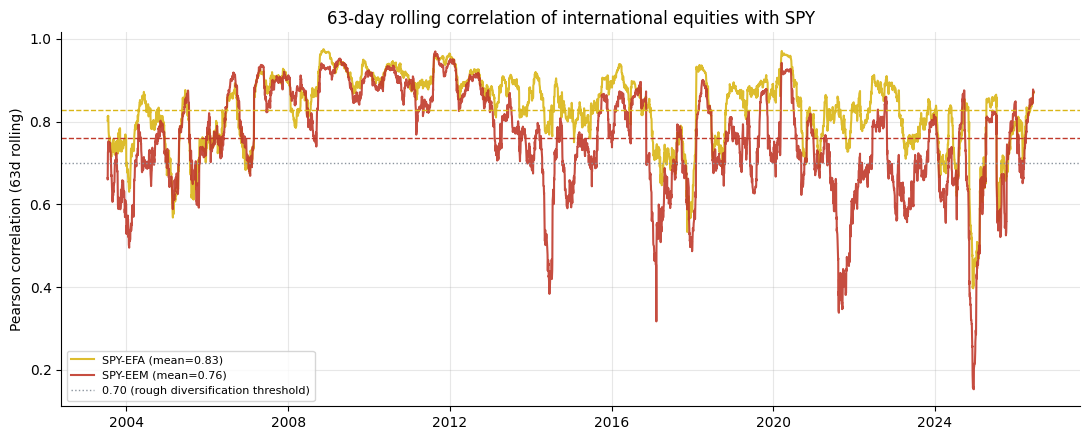

In [4]:
if HAVE_REAL:
    corr_efa = st.rolling_correlation(ret, 'SPY', 'EFA')
    corr_eem = st.rolling_correlation(ret, 'SPY', 'EEM')
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(corr_efa, label=f'SPY-EFA (mean={corr_efa.mean():.2f})', color=AMBER, alpha=0.9)
    ax.plot(corr_eem, label=f'SPY-EEM (mean={corr_eem.mean():.2f})', color=RED, alpha=0.9)
    ax.axhline(corr_efa.mean(), ls='--', c=AMBER, lw=1)
    ax.axhline(corr_eem.mean(), ls='--', c=RED, lw=1)
    ax.axhline(0.7, ls=':', c=GREY, lw=1, label='0.70 (rough diversification threshold)')
    ax.set_title('63-day rolling correlation of international equities with SPY')
    ax.set_ylabel('Pearson correlation (63d rolling)'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print(f'SPY-EFA rolling corr: mean={R["corr_efa_mean"]:.2f}  min={R["corr_efa_min"]:.2f}  max={R["corr_efa_max"]:.2f}')
    print(f'SPY-EEM rolling corr: mean={R["corr_eem_mean"]:.2f}  min={R["corr_eem_min"]:.2f}  max={R["corr_eem_max"]:.2f}')

SPY-EFA averaged **0.83** and SPY-EEM **0.76**. These are very high correlations — financial globalisation has made equity markets move together. The diversification benefit requires correlations well below 0.7; at 0.83 the variance-reduction from adding EFA is modest at best. And when the US also earns 3%/yr more than EFA, the modest risk reduction cannot compensate.

> 💡 The free lunch is mathematical: it requires low correlation *and* competitive returns. When the US earned more AND correlations were high, both levers pointed against the blend.

## 5 · The verdict

- **Signal — None.** Blend Sharpe 0.515 < US-only 0.591; blend return 10.0% < US 11.0%; deeper drawdown. No diversification benefit materialised.
- **Tradability — Mirage.** At zero cost the blend underperforms on every axis. There is nothing to trade here.
- **Diversification benefit? Correlation killed it.** SPY-EFA averaged 0.83 — far too high for meaningful variance reduction. And the US structural return edge (+3%/yr) overrode any marginal benefit.

## 6 · Could you actually trade it?

The good news: the *cost* of implementing the 60/25/15 blend is tiny. Annual rebalancing trades ~5% of notional; at 2 bps round-trip that's ~0.1 bps/yr — effectively free. The problem isn't execution: the blend simply underperforms before costs. You would be paying to own a portfolio with **lower Sharpe, lower return, and deeper drawdowns** than staying home.

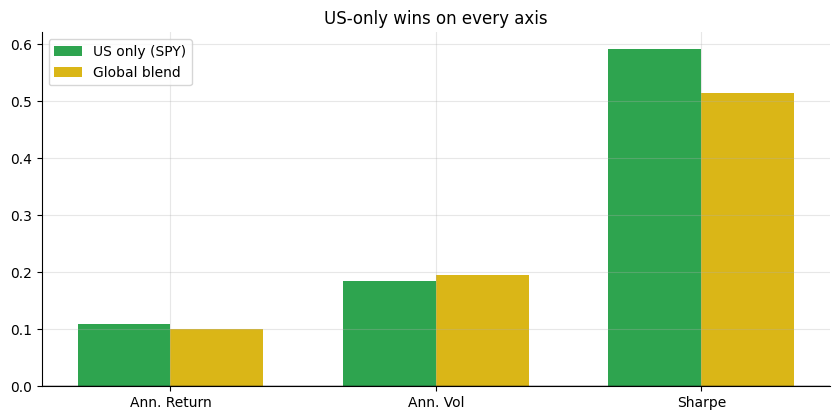

In [5]:
if HAVE_REAL:
    s_us  = st.portfolio_stats(us_ret)
    s_bl  = st.portfolio_stats(blend)
    fig, ax = plt.subplots(figsize=(8.5, 4.3))
    metrics = ['ann_return', 'ann_vol', 'sharpe']
    labels_m = ['Ann. Return', 'Ann. Vol', 'Sharpe']
    x = range(len(metrics))
    w = 0.35
    ax.bar([i-w/2 for i in x], [s_us[m] for m in metrics], width=w, label='US only (SPY)', color=GREEN)
    ax.bar([i+w/2 for i in x], [s_bl[m] for m in metrics], width=w, label='Global blend', color=AMBER)
    ax.set_xticks(list(x)); ax.set_xticklabels(labels_m)
    ax.axhline(0, c='k', lw=1); ax.set_title('US-only wins on every axis'); ax.legend()
    plt.tight_layout(); plt.show()
else:
    print('US only: ann=+10.97%  vol=18.6%  sharpe=0.591')
    print('Blend:   ann=+10.01%  vol=19.4%  sharpe=0.515')
    print('=> Blend loses on every axis before costs.')

> 💡 Annual rebalancing costs are negligible (~0.1 bps/yr). The blend underperforms *before* costs — there is no cost level at which it becomes sensible, because the issue is not execution friction but the realised return/risk of the assets.

## 7 · Going further

- **Is the future different from the past?** The theoretical case for international diversification is forward-looking: if US valuations are high (CAPE > 30) and international valuations cheap (CAPE ~15), the *forward* expected return spread may reverse. This study only measures what happened. Future US underperformance would make the blend look better.
- **What if you held bonds?** Adding non-equity assets (TLT, GLD) can genuinely diversify because correlations with equities are lower. [Study 68 — All-Weather](../../68-all-weather/) tests exactly this — and finds the Sharpe improvement is modest but real on the risk-parity frame.
- **Currency risk.** EFA and EEM are unhedged; a strong dollar (post-2009) depressed their USD returns. A currency-hedged EFA (ticker HEFA) would show slightly higher returns — but still lower than SPY.
- **What correlation would make diversification work?** Below ~0.50 and with equal expected returns, theory predicts a Sharpe improvement. That was the world in the 1970-1990s. The synthetic demo shows the machine works when conditions are right — the real market since 2003 just didn't have those conditions.

*Think the free lunch is back? Check current international CAPE vs US CAPE, and the recent SPY-EFA rolling 63-day correlation. That's the data you'd want before tilting the allocation.*